## 项目：可视化帕默群岛企鹅数据

### 分析目标

此数据分析报告的目的是对帕默群岛上企鹅样本的相关变量进行可视化，从而探索和分析种类、性别、所在岛屿等因素，与企鹅的身体属性，包括体重、嘴峰长度和深度、鳍的长度，之间的关系。

### 简介

原始数据Penguins.csv包括334个收集自南极洲帕尔默群岛的3个岛屿上的企鹅样本，以及企鹅相关属性数据，包括种类名、所在岛、嘴峰长度、嘴峰深度、鳍长度、体重、性别。

`Penguins.csv`每列的含义如下：
- species：企鹅的种类
- island：企鹅所在岛
- culmen_length_mm：企鹅嘴峰的长度（单位为毫米）
- culmen_depth_mm：企鹅嘴峰的深度（单位为毫米）
- flipper_length_mm：企鹅鳍的长度（单位为毫米）
- body_mass_g：企鹅体重（单位为克）
- sex：企鹅性别

### 读取数据

导入数据分析所需要的库，并通过Pandas的read_csv函数，将原始数据文件Penguins.csv里的数据内容，解析为DataFrame并赋值给变量original_data。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
original_data = pd.read_csv("Penguins.csv")
original_data.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


### 评估和数据清理

在这一部分中，我们将对在上一部分建立的original_dataDataFrame所包含的数据进行评估和清理。

主要从两个方面进行：结构和内容，即整齐度和干净度。

数据的结构性问题指不符合“每个变量为一列，每个观察值为一行，每种类型的观察单位为一个表格”这三个标准；数据的内容性问题包括存在丢失数据、重复数据、无效数据等。

为了区分开经过清理的数据和原始的数据，我们创建新的变量cleaned_data，让它为original_data复制出的副本。我们之后的清理步骤都将被运用在cleaned_data上。

In [3]:
cleaned_data = original_data.copy()

#### 数据整齐度

In [4]:
cleaned_data.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,female,2007
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,male,2007
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN,2007
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN,2007


**评估结果**：从头部的10行数据来看，数据符合“每个变量为一列，每个观察值为一行，每种类型的观察单位为一个表格”，因此不存在结构性问题。

#### 数据干净度

In [5]:
# 接下来通过info，对数据内容进行大致了解。
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 21.6 KB


**评估结果**：

从输出结果来看，`cleaned_data`数据共有344条观察值，`bill_length_mm`、`bill_depth_mm`、`flipper_length_mm`、`body_mass_g`变量存在缺失值，将在后续进行评估和清理。

数据类型方面，我们已知`species`（企鹅种类）、`sex`（企鹅性别）、`island`（企鹅所在岛）都是分类数据，因此可以把数据类型都转换为`Category`。

#### 处理缺失数据

从输出结果来看，`cleaned_data`数据共有344条观察值，`bill_length_mm`、`bill_depth_mm`、`flipper_length_mm`、`body_mass_g`变量存在缺失值，将在后续进行评估和清理。

先提取出缺失这些变量的观察值进行查看。

In [6]:
cleaned_data.query("bill_length_mm.isna()")

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
271,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN,2009


In [7]:
cleaned_data.query("bill_depth_mm.isna()")

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
271,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN,2009


In [8]:
cleaned_data.query("flipper_length_mm.isna()")

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
271,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN,2009


In [9]:
cleaned_data.query("body_mass_g.isna()")

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
271,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN,2009


**查询结果**：以上，可以看到索引为3和339的观察值，除了种类和所属岛屿外所有变量都为空，无法为探索企鹅身体属性相关因素提供价值，因此可以把这两行直接删除。

In [10]:
cleaned_data.drop(3, inplace=True)
cleaned_data.drop(339, inplace=True)

In [11]:
cleaned_data.query("sex.isna()")

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN,2007
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN,2007
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN,2007
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN,2007
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN,2007
178,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN,2007
218,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN,2008
256,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN,2009
268,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN,2009
271,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN,2009


**查询结果**：缺失性别变量的观察值具备其它数据，仍然可以为分析提供价值。由于Pandas以及Matplotlib、Seaborn会自动忽略缺失值，可以保留这些行。

#### 处理重复数据

根据数据变量的含义以及内容来看，允许变量重复，我们不需要对此数据检查是否存在重复值。

#### 处理不一致数据

不一致数据可能存在于所有分类变量中，我们要查看是否存在不同值实际指代同一目标的情况。

In [12]:
cleaned_data["species"].value_counts()

species
Adelie       151
Gentoo       124
Chinstrap     67
Name: count, dtype: int64

In [13]:
cleaned_data["island"].value_counts()

island
Biscoe       168
Dream        123
Torgersen     51
Name: count, dtype: int64

In [14]:
cleaned_data["sex"].value_counts()

sex
male      167
female    165
Name: count, dtype: int64

从以上输出来看，`species`和`island`以及`sex`列里并不存在不一致数据

#### 处理无效或错误数据

可以通过DataFrame的describe方法，对数值统计信息进行快速了解。

In [16]:
cleaned_data.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,341.000000,341.000000,341.000000,341.000000,342.000000
mean,43.887097,17.143402,200.897361,4202.346041,2008.029240
std,5.429414,1.972456,14.078499,803.058259,0.817168
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.200000,15.600000,190.000000,3550.000000,2007.000000
50%,44.400000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


**评估结果**：从以上统计信息来看，cleaned_house_price里不存在脱离现实意义的数值。

### 数据探索

我们将通过数据可视化，进行探索和分析，从图表中获得企鹅样本数据的相关洞察。

In [18]:
# 设置图表色盘为"pastel"，后面所有的图表都会以那个色盘进行绘制
sns.set_palette("pastel")

In [19]:
cleaned_data

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007
...,...,...,...,...,...,...,...,...
338,Chinstrap,Dream,45.7,17.0,195.0,3650.0,female,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


#### 企鹅种类比例

绘制饼图，我们需要一个类似像：种类a有多少个，种类b有多少个……

In [21]:
# 得到各个种类对应的样本数量
cleaned_data.groupby("species")["island"].count()

species
Adelie       151
Chinstrap     67
Gentoo       124
Name: island, dtype: int64

In [23]:
# Series中有一个value_counts方法，直接返回Series里各个种类对应的个数
species_count = cleaned_data["species"].value_counts()

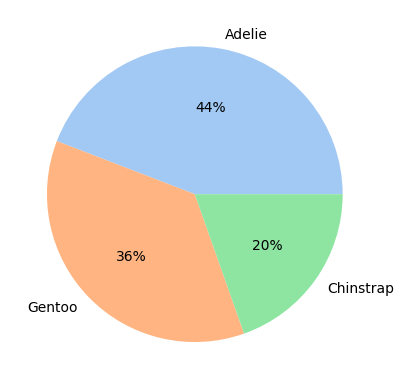

In [28]:
# autopct在饼图上添加百分比(.0f表示保留0位小数)
# 我们传入的species_count正好就是需要的标签值，而且索引和数字是肯定对应的，所以直接传入index即可
plt.pie(species_count, autopct='%.0f%%', labels=species_count.index)
plt.show()

样本中Adelie这个种类的企鹅占比最大，Gentoo种类的占比次之，Chinstrap的占比最小，为1/5左右。

#### 企鹅所属岛屿比例

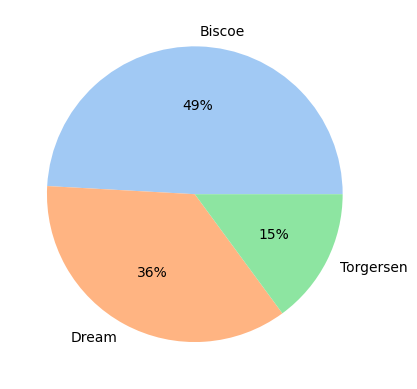

In [29]:
island_count = cleaned_data["island"].value_counts()
plt.pie(island_count, autopct="%.0f%%", labels=island_count.index)
plt.show()

样本中一半左右的企鹅样本都来自Biscoe岛屿，占比最大，其次是Dream岛屿，来自Torgersen岛屿的样本最少。

#### 企鹅性别比例

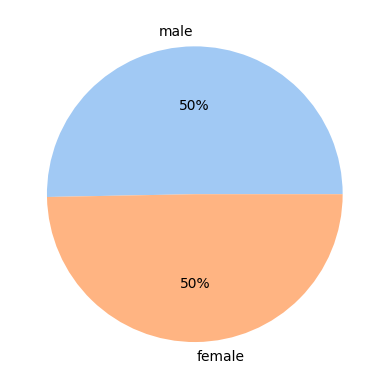

In [30]:
set_count = cleaned_data['sex'].value_counts()
plt.pie(set_count, autopct="%.0f%%", labels=set_count.index)
plt.show()

样本企鹅的性别占比持平，符合随机抽样

#### 不同岛上的企鹅种类数量

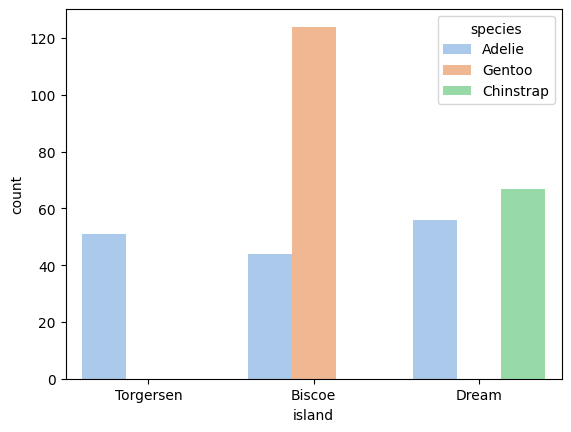

In [33]:
# 由于countplot的原因，所以y轴自动就是各个岛屿样本对应的个数
# 通过hue来指定不同种类的颜色
sns.countplot(cleaned_data, x="island", hue="species")
plt.show()

#### 不同岛屿上的企鹅性别数量

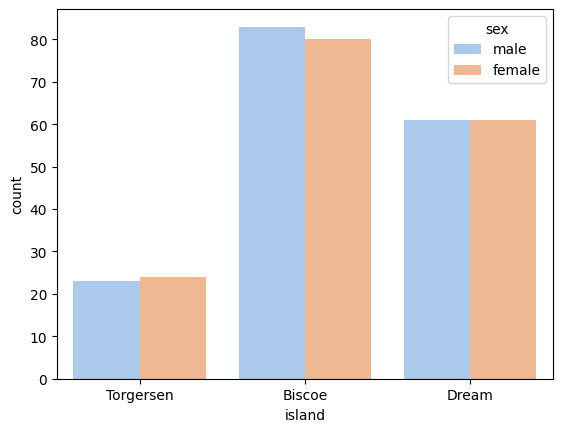

In [34]:
sns.countplot(cleaned_data, x='island', hue='sex')
plt.show()

#### 查看数值之间的相关关系

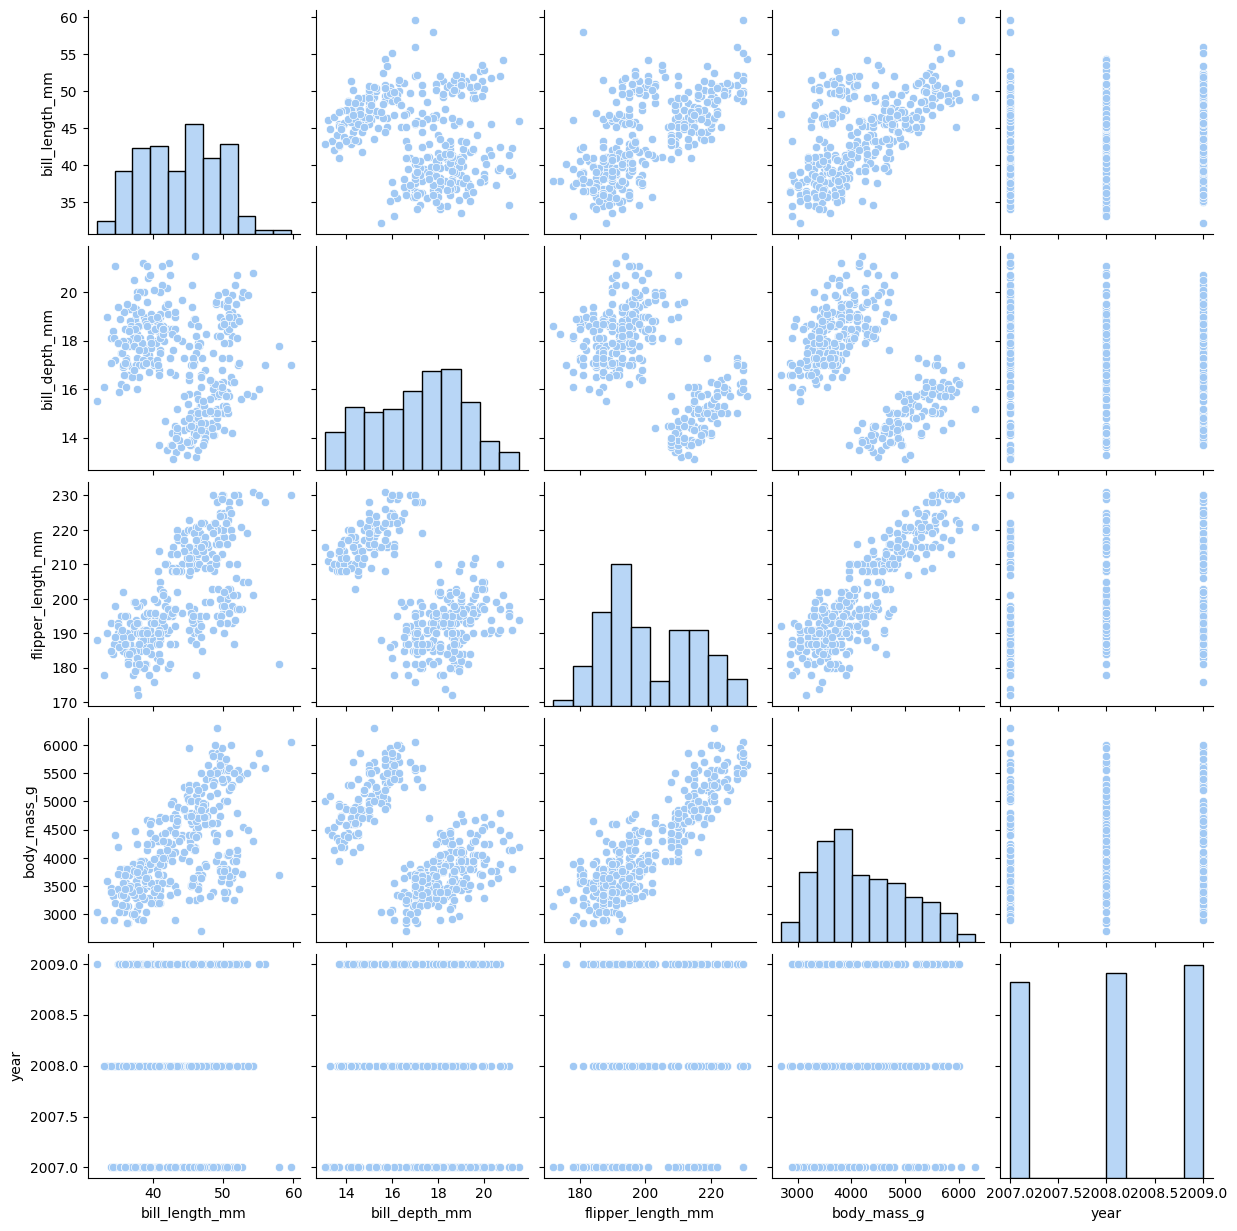

In [36]:
sns.pairplot(cleaned_data)
plt.show()

从直方图来看，企鹅样本的嘴峰长度、嘴峰深度、鳍长度、体重的分布不是正态分布。一方面说明，这里面可能包含了多组存在差异的样本数据，另一方面也说明样本数不够大。

另外可以在散点图中看出明显的多个集群，可能与某些因素有关，比如企鹅种类、性别，因此可以对对比进行进一步的分类。

#### 根据种类查看数值之间的相关关系

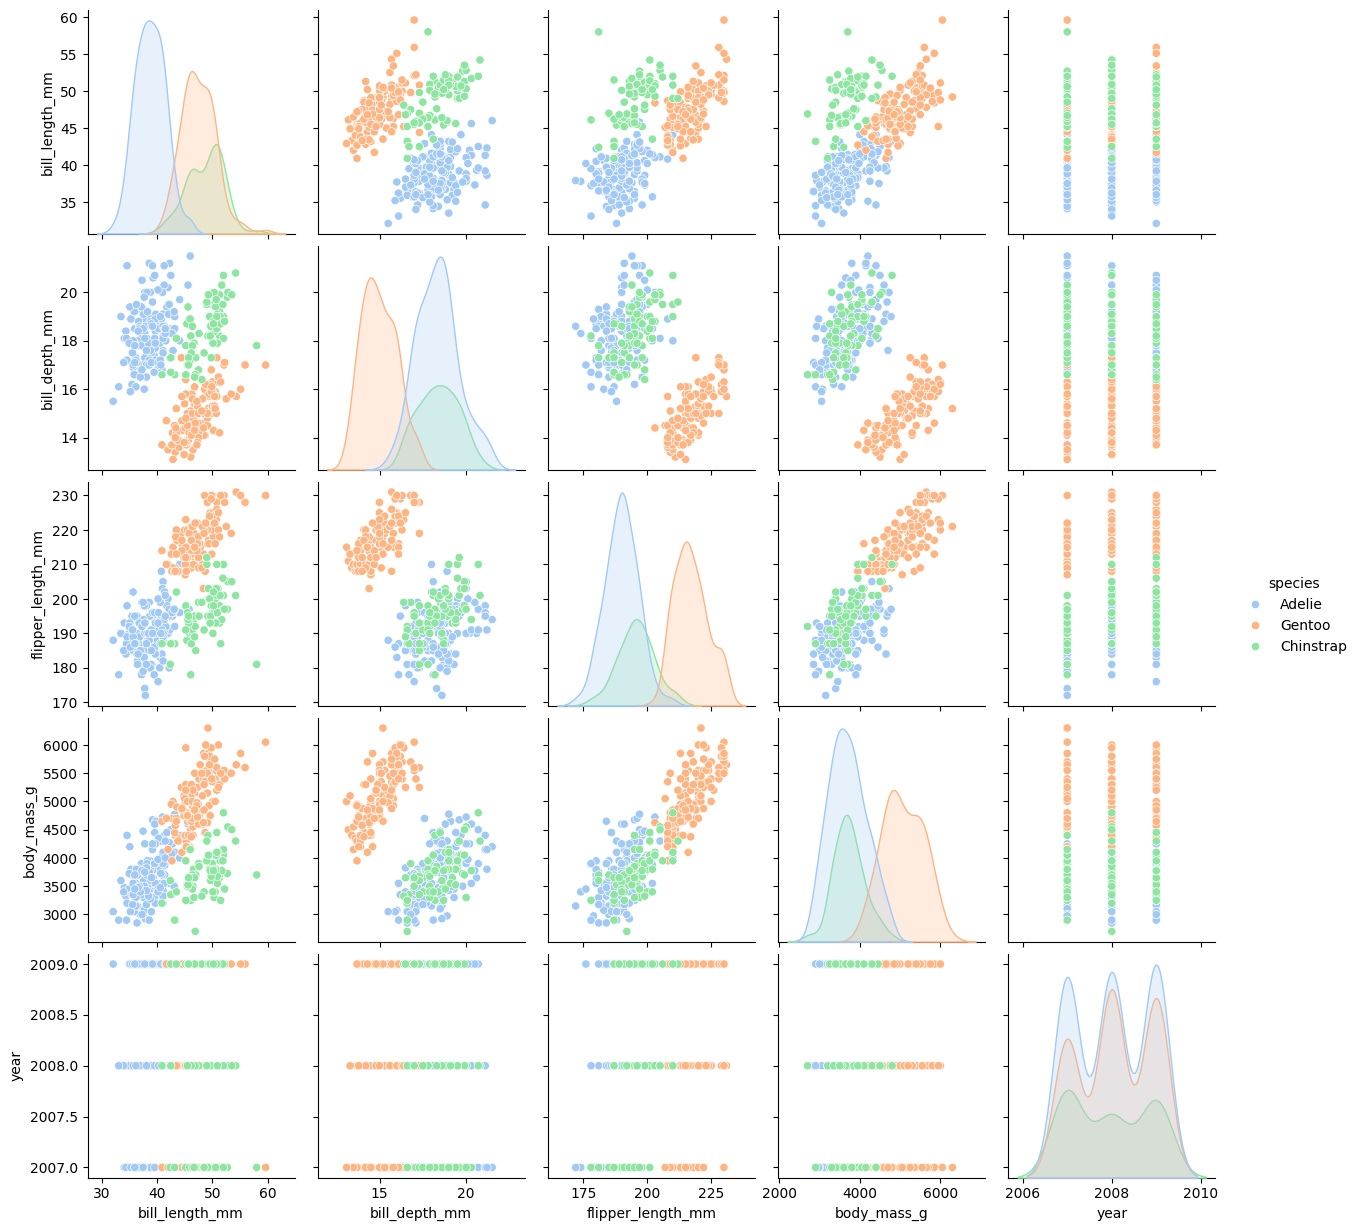

In [37]:
sns.pairplot(cleaned_data, hue='species')
plt.show()

同一种类的企鹅样本数据，在散点图上基本都聚在一起，说明同一种类的企鹅在嘴峰长度、嘴峰深度、鳍长度、体重之间关系上，存在相似性。这些发现有利于我们根据体重、鳍长等数值推测企鹅种类，也可以根据企鹅种类推测体重、鳍长等数值。

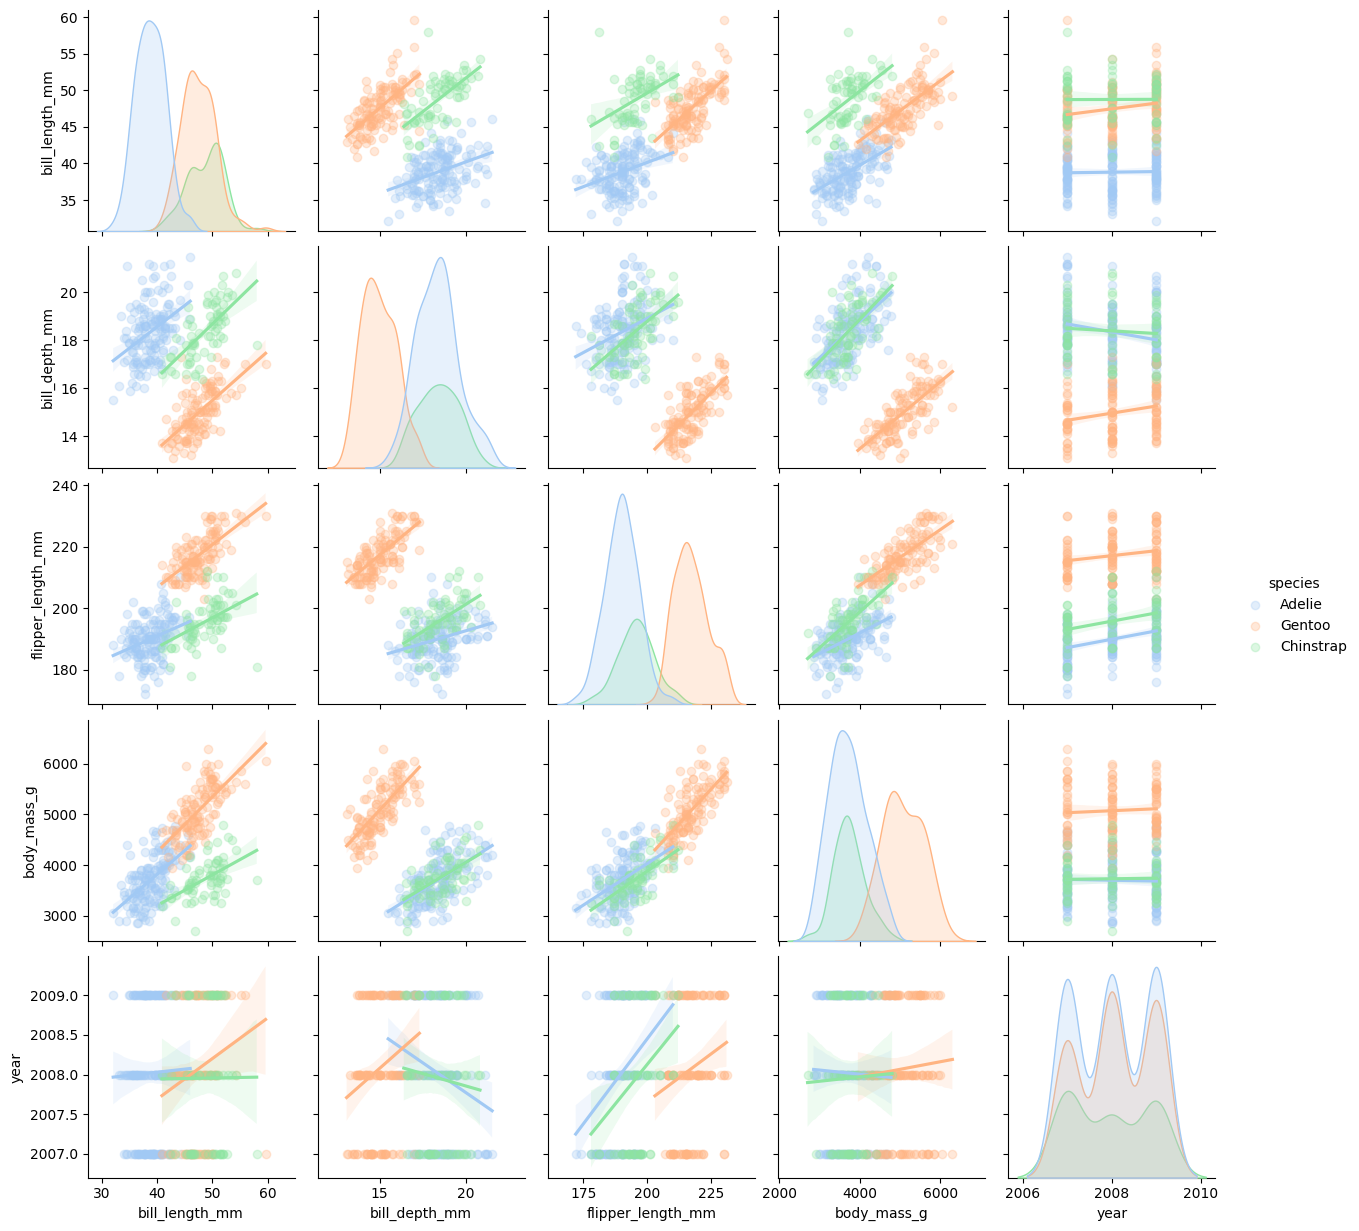

In [41]:
# 参数kind='reg', 回归线，能够大致表现散点的趋势
# 调整透明度plot_kws
# 我们现在要调整的是散点图的透明度，所以使用scatter_kws
# 透明度alpha，1表示不透明，0表示全透明
sns.pairplot(cleaned_data, hue='species', kind='reg', plot_kws={'scatter_kws': {'alpha': 0.3}})
plt.show()

散点图结合线性回归线来看，同类企鹅的属性数据之间均呈线性正比，即嘴峰越长，嘴峰越深，鳍越长，体重越重，嘴峰越短，嘴峰越浅，鳍越短，体重越轻。

从密度图的分布来看，可以得到以下关于样本的发现：
- Chinstrap和Gentoo的嘴峰长度范围较为接近，而Adelie的嘴峰长度更短。
- Adelie和Chinstrap的嘴峰深度范围较为接近，而Gentoo的嘴峰深度更短。
- Adelie的鳍长度最短，Chinstrap中等，而Gentoo的鳍长度嘴长。
- Adelie和Chinstrap的体重范围较为接近，而Gentoo的体重更大。

但不同种类的属性数值否存在统计显著性差异，仍然需要进行假设检验后才能得到结论。

#### 根据性别查看数值之间的相关关系

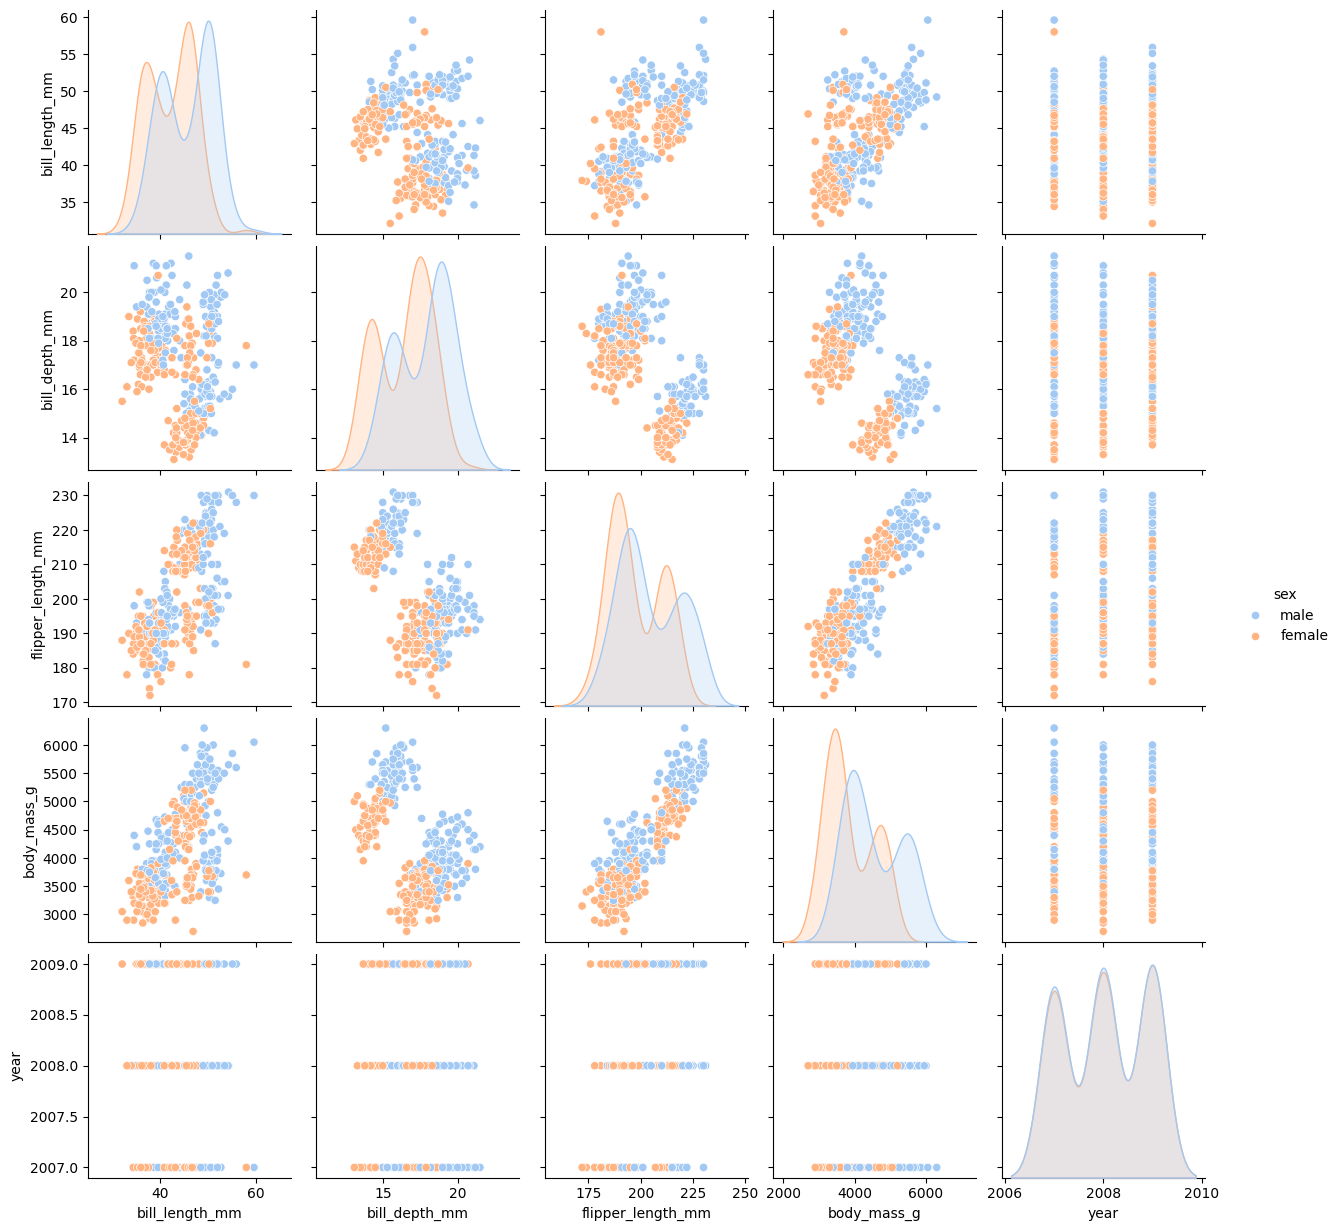

In [45]:
sns.pairplot(cleaned_data, hue='sex')
plt.show()

根据性别划分后可以看出，样本中雄性企鹅在各项属性数值方面大于雌性企鹅。